In [159]:
import numpy as np
import matplotlib.pyplot as plt

In [160]:
#load data
data = np.loadtxt('data/channel_data.txt')
lat = data[:,0]
lon = data[:, 1]
h = data[:, 2]

In [161]:
# haversine formula for calculating distances
def haversine(lat1,lon1,lat2,lon2):
    R = 6371000.0 # Earth radius
    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)
    lat_diff = lat2_rad - lat1_rad
    lon_diff = np.radians(lon2 - lon1)

    a = np.sin(lat_diff / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(lon_diff / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

In [162]:
# distance loop
dist = np.zeros(len(lat))
for i in range(1, len(lat)):
    dist[i] = dist[i - 1] + haversine(lat[i - 1], lon[i - 1], lat[i], lon[i])

# interpolate height
dist_250 = np.arange(0, dist[-1] + 250, 250)
h_250 = np.interp(dist_250, dist, h)

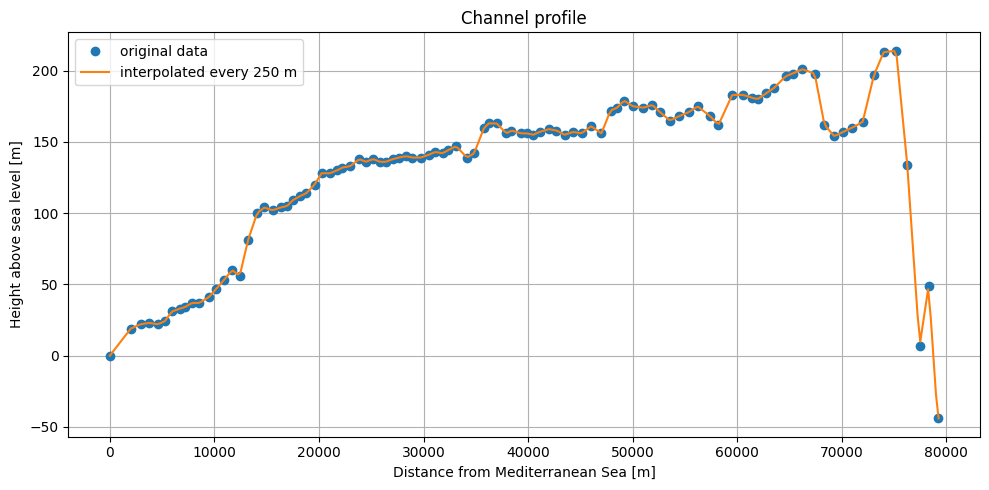

In [163]:
# plot channel profile
plt.figure(figsize=(10, 5))
plt.plot(dist, h, "o", label="original data")
plt.plot(dist_250, h_250, "-", label="interpolated every 250 m")
plt.xlabel("Distance from Mediterranean Sea [m]")
plt.ylabel("Height above sea level [m]")
plt.title("Channel profile")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [164]:
np.savetxt("data/channel_heights.txt", h_250, fmt="%.6f")

## 3

In [165]:
R = np.loadtxt("data/R_values.txt")
x = np.arange(len(R))
bomb_dist = np.loadtxt("data/bomb_positions.txt")
bomb_height = np.interp(bomb_dist, dist_250, h_250)

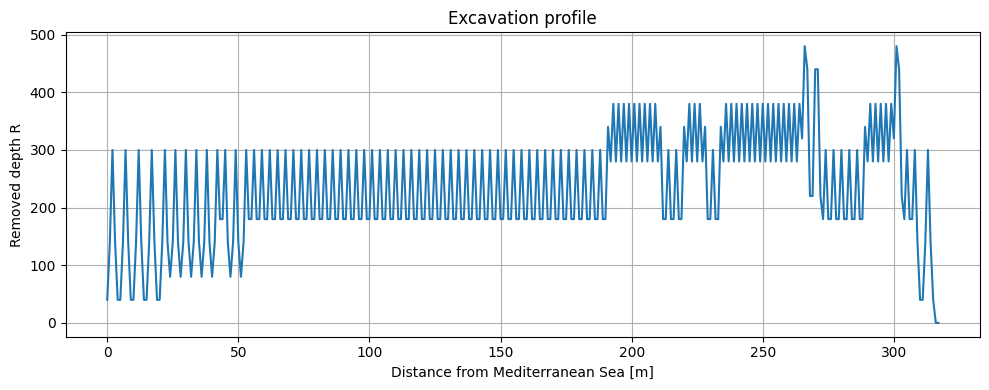

In [166]:
plt.figure(figsize=(10, 4))
plt.plot(x, R)
plt.xlabel("Distance from Mediterranean Sea [m]")
plt.ylabel("Removed depth R")
plt.title("Excavation profile")
plt.grid(True)
plt.tight_layout()
plt.show()

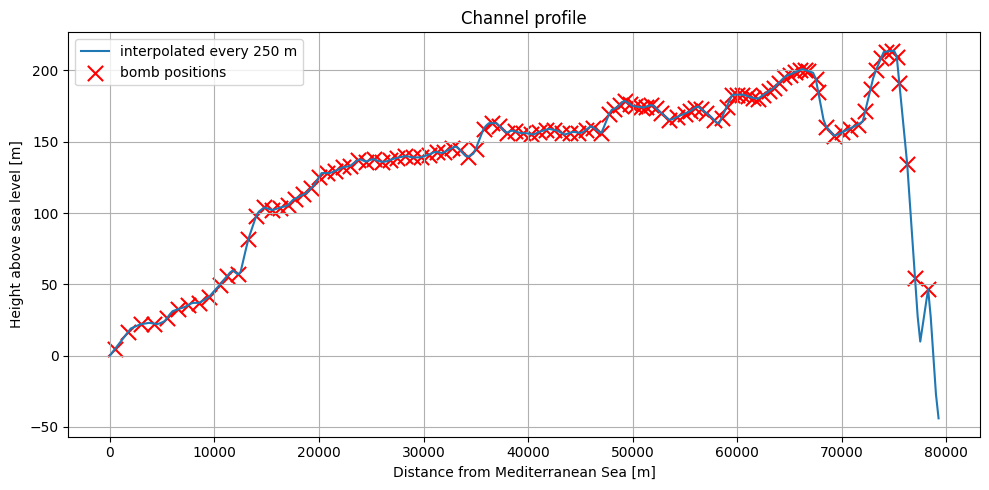

In [167]:
plt.figure(figsize=(10, 5))
plt.plot(dist_250, h_250, "-", label="interpolated every 250 m")
plt.scatter(bomb_dist, bomb_height, marker="x", color="red", s=120, label="bomb positions")
plt.xlabel("Distance from Mediterranean Sea [m]")
plt.ylabel("Height above sea level [m]")
plt.title("Channel profile")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 6


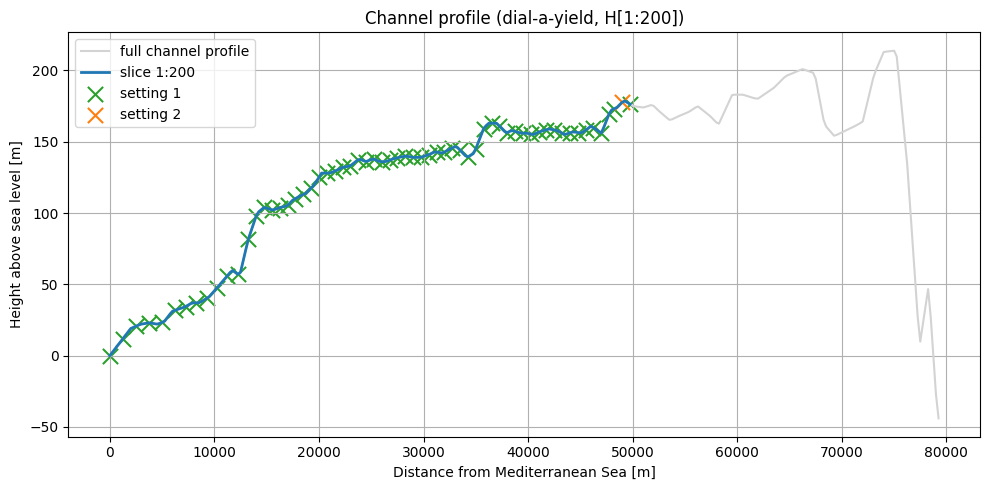

In [ ]:
R6 = np.loadtxt("data/dial_yield_R_values.txt")
bomb_dist6 = np.loadtxt("data/dial_yield_positions.txt")
bomb_setting6 = np.loadtxt("data/dial_yield_settings.txt")

slice_start_idx = 268
start0 = slice_start_idx - 1
n6 = len(R6)

dist6 = dist_250[start0:start0 + n6]
h6 = h_250[start0:start0 + n6]
bomb_dist6_global = bomb_dist6 + start0 * 250

plt.figure(figsize=(10, 5))
plt.plot(dist_250, h_250, "-", color="lightgray", label="full channel profile")
plt.plot(dist6, h6, "-", color="tab:blue", linewidth=2, label="slice 1:200")

setting_colors = {1: "tab:green", 2: "tab:orange", 3: "tab:red"}
for s in [1, 2, 3]:
    mask = bomb_setting6.astype(int) == s
    if np.any(mask):
        bomb_height_s = np.interp(bomb_dist6_global[mask], dist_250, h_250)
        plt.scatter(
            bomb_dist6_global[mask],
            bomb_height_s,
            marker="x",
            color=setting_colors[s],
            s=120,
            label=f"setting {s}"
        )

plt.xlabel("Distance from Mediterranean Sea [m]")
plt.ylabel("Height above sea level [m]")
plt.title("Channel profile (dial-a-yield, H[1:200])")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
